# Modelagem — UNESCO World Heritage Sites

Notebook de modelagem construído sobre o dataset processado em `01_eda.ipynb`.

| Fase | Conteúdo |
|---|---|
| **1** | Análise temporal — série histórica por década, categoria e região |
| **2** | Similaridade por NLP — TF-IDF + similaridade cosseno sobre `full_text` |
| **3** | Clustering geográfico — DBSCAN com `metric="haversine"` |

## Importações

In [ ]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

NORD_PALETTE = [
    "#88C0D0", "#A3BE8C", "#EBCB8B",
    "#BF616A", "#B48EAD", "#D08770", "#81A1C1",
]

sns.set_theme(style="darkgrid", palette=NORD_PALETTE)
plt.rcParams.update({
    "figure.facecolor": "#2E3440",
    "axes.facecolor": "#3B4252",
    "text.color": "#ECEFF4",
    "axes.labelcolor": "#ECEFF4",
    "xtick.color": "#D8DEE9",
    "ytick.color": "#D8DEE9",
    "axes.edgecolor": "#4C566A",
    "grid.color": "#434C5E",
    "axes.titlecolor": "#ECEFF4",
    "legend.facecolor": "#3B4252",
    "legend.edgecolor": "#4C566A",
})

## Carregamento dos Dados

In [ ]:
PROCESSED_PATH = Path("..") / "data" / "processed" / "whc_processed.csv"

df = pd.read_csv(PROCESSED_PATH, sep=";", encoding="utf-8")
print(f"Shape: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
df[["name_en", "year_inscribed", "decade_inscribed", "category", "region"]].head()

# 1. Análise Temporal

Evolução das inscrições ao longo do tempo, analisada em três eixos.

## 1.1 Série histórica de inscrições por década

In [ ]:
temporal = (
    df.dropna(subset=["decade_inscribed"])
    .assign(decade=lambda x: x["decade_inscribed"].astype(float).astype(int))
    .groupby("decade")
    .size()
    .rename("count")
    .reset_index()
)

x = np.arange(len(temporal))
coeffs = np.polyfit(x, temporal["count"].values, 1)
trend_y = np.poly1d(coeffs)(x)
peak_idx = int(temporal["count"].idxmax())

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(x, temporal["count"], color="#88C0D0", edgecolor="#2E3440", width=0.7)
bars[peak_idx].set_color("#EBCB8B")

for bar, val in zip(bars, temporal["count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        str(int(val)),
        ha="center", color="#ECEFF4", fontsize=10,
    )

ax.plot(
    x, trend_y,
    color="#BF616A", linewidth=2, linestyle="--",
    label=f"Tendência linear ({'+' if coeffs[0] >= 0 else ''}{coeffs[0]:.1f} sítios/década)",
)

ax.set_xticks(x)
ax.set_xticklabels(temporal["decade"].astype(str))
ax.set_title("Inscrições por Década", fontsize=14, fontweight="bold")
ax.set_xlabel("Década")
ax.set_ylabel("Número de Sítios")
ax.legend()
plt.tight_layout()
plt.show()

peak_decade = temporal.loc[peak_idx, "decade"]
print(f"Pico: década de {peak_decade}s — {temporal.loc[peak_idx, 'count']} inscrições")
print(f"Total acumulado: {temporal['count'].sum():,} sítios")

## 1.2 Composição por categoria ao longo das décadas

In [ ]:
cat_decade = (
    df.dropna(subset=["decade_inscribed"])
    .assign(decade=lambda x: x["decade_inscribed"].astype(float).astype(int))
    .groupby(["decade", "category"])
    .size()
    .unstack(fill_value=0)
)
cat_decade_pct = cat_decade.div(cat_decade.sum(axis=1), axis=0) * 100

cat_colors = {"Cultural": "#81A1C1", "Natural": "#A3BE8C", "Mixed": "#EBCB8B"}
categories = [c for c in ["Cultural", "Natural", "Mixed"] if c in cat_decade.columns]
x = np.arange(len(cat_decade))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for ax, data, title, ylabel in [
    (ax1, cat_decade, "Absoluto", "Número de Sítios"),
    (ax2, cat_decade_pct, "Proporcional (%)", "%"),
]:
    bottom = np.zeros(len(data))
    for cat in categories:
        vals = data[cat].values
        ax.bar(x, vals, bottom=bottom, label=cat, color=cat_colors[cat], edgecolor="#2E3440", width=0.7)
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels(cat_decade.index.astype(str))
    ax.set_title(title)
    ax.set_xlabel("Década")
    ax.set_ylabel(ylabel)
    ax.legend()

fig.suptitle("Composição por Categoria ao Longo das Décadas", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

print("Proporção média por categoria:")
print(cat_decade_pct.mean().round(1).rename("%").to_string())

## 1.3 Distribuição por região e década

In [ ]:
REGION_SHORT: dict[str, str] = {
    "Europe and North America": "Europa / N. América",
    "Asia and the Pacific": "Ásia / Pacífico",
    "Latin America and the Caribbean": "América Latina",
    "Africa": "África",
    "Arab States": "Estados Árabes",
}

region_decade = (
    df.dropna(subset=["decade_inscribed"])
    .assign(decade=lambda x: x["decade_inscribed"].astype(float).astype(int))
    .groupby(["region", "decade"])
    .size()
    .unstack(fill_value=0)
)
region_decade.index = region_decade.index.map(lambda r: REGION_SHORT.get(r, r))
region_decade = region_decade.loc[region_decade.sum(axis=1).sort_values(ascending=False).index]

nord_seq = LinearSegmentedColormap.from_list("nord_seq", ["#3B4252", "#5E81AC", "#88C0D0"])

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    region_decade,
    annot=True,
    fmt="d",
    cmap=nord_seq,
    linewidths=0.5,
    linecolor="#2E3440",
    ax=ax,
    cbar_kws={"shrink": 0.7, "label": "Inscrições"},
)
ax.set_title("Inscrições por Região e Década", fontsize=14, fontweight="bold")
ax.set_xlabel("Década")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print("Total por região:")
print(region_decade.sum(axis=1).rename("total").to_string())

# 2. Similaridade por NLP

Representação vetorial dos sítios a partir de `full_text` (nome + descrição em inglês) via **TF-IDF**,
seguida de **similaridade cosseno** para identificar sítios com vocabulário descritivo similar.

## 2.1 Vetorização TF-IDF

`TfidfVectorizer` com unigramas e bigramas (`ngram_range=(1, 2)`), `sublinear_tf=True`
para reduzir o peso de termos muito frequentes e `stop_words="english"`.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

nlp_df = df.dropna(subset=["full_text"]).reset_index(drop=True)

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=8_000,
    sublinear_tf=True,
    ngram_range=(1, 2),
    min_df=2,
)
tfidf_matrix = vectorizer.fit_transform(nlp_df["full_text"])
feature_names = np.array(vectorizer.get_feature_names_out())

n_docs, n_terms = tfidf_matrix.shape
sparsity = (1 - tfidf_matrix.nnz / (n_docs * n_terms)) * 100

print(f"Documentos  : {n_docs:,}")
print(f"Vocabulário : {n_terms:,} termos")
print(f"Esparsidade : {sparsity:.1f}%")

Documentos  : 1,248
Vocabulário : 8,000 termos
Esparsidade : 99.3%


## 2.2 Termos mais relevantes por categoria

Soma dos scores TF-IDF de todos os documentos de cada categoria — revela o vocabulário
característico de sítios Culturais, Naturais e Mistos.

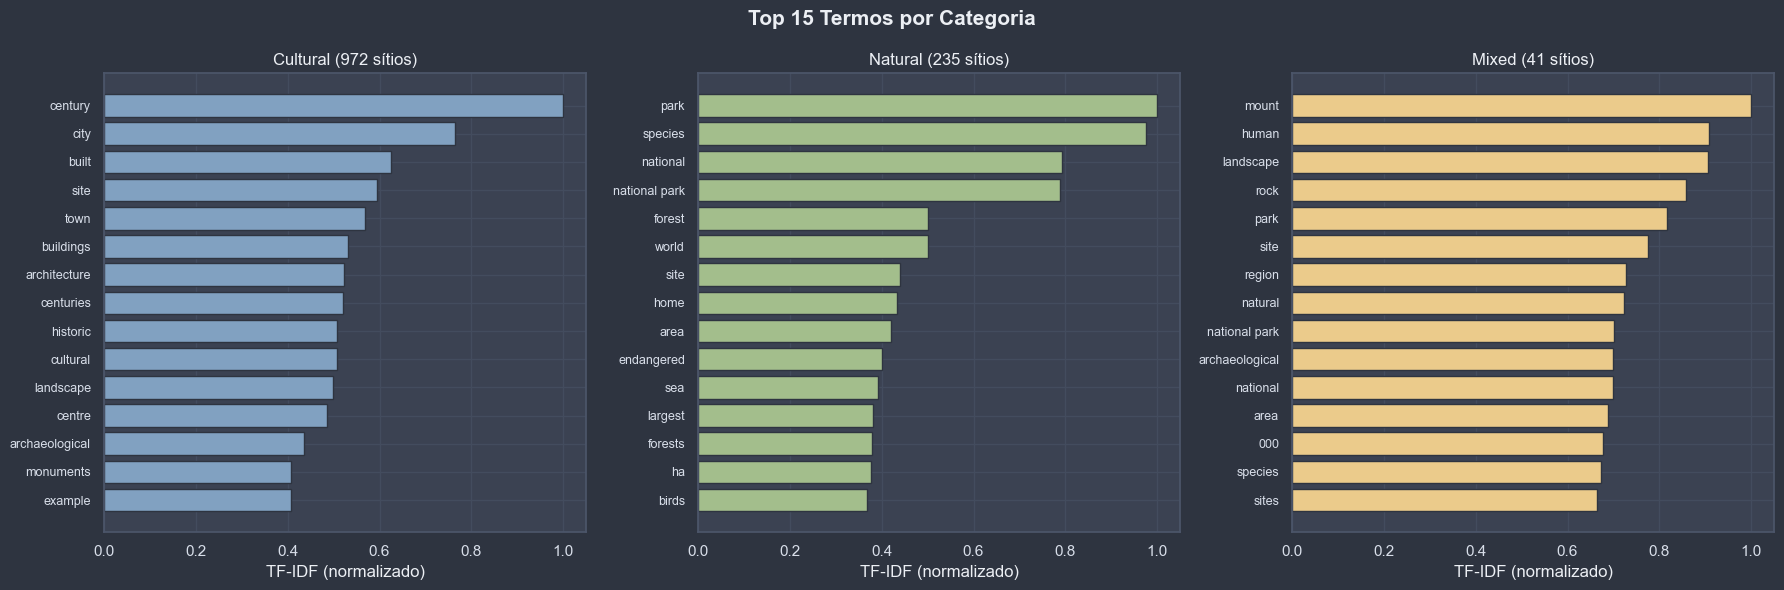

In [18]:
top_n_terms = 15
cat_colors_map: dict[str, str] = {
    "Cultural": "#81A1C1",
    "Natural": "#A3BE8C",
    "Mixed": "#EBCB8B",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, cat in zip(axes, ["Cultural", "Natural", "Mixed"]):
    mask = (nlp_df["category"] == cat).to_numpy()
    cat_tfidf_sum = np.asarray(tfidf_matrix[mask].sum(axis=0)).flatten()
    top_idx = cat_tfidf_sum.argsort()[::-1][:top_n_terms]
    top_terms = feature_names[top_idx]
    top_scores = cat_tfidf_sum[top_idx] / cat_tfidf_sum[top_idx].max()

    ax.barh(
        range(top_n_terms, 0, -1),
        top_scores,
        color=cat_colors_map.get(cat, "#88C0D0"),
        edgecolor="#2E3440",
    )
    ax.set_yticks(range(top_n_terms, 0, -1))
    ax.set_yticklabels(top_terms, fontsize=9)
    ax.set_title(f"{cat} ({mask.sum()} sítios)")
    ax.set_xlabel("TF-IDF (normalizado)")

fig.suptitle("Top 15 Termos por Categoria", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## 2.3 Consulta de similaridade

`linear_kernel` computa a similaridade cosseno entre o vetor do sítio consultado e todos os
demais (equivalente a `cosine_similarity` para vetores L2-normalizados, porém mais eficiente
para matrizes esparsas).

In [19]:
from sklearn.metrics.pairwise import linear_kernel


def find_similar_sites(site_name: str, top_n: int = 8) -> pd.DataFrame:
    """Returns the top_n UNESCO sites most similar to site_name by TF-IDF cosine similarity."""
    matches = nlp_df[nlp_df["name_en"].str.contains(site_name, case=False, na=False)]
    if matches.empty:
        raise ValueError(f"Nenhum sítio encontrado com '{site_name}'")
    idx = int(matches.index[0])
    scores = linear_kernel(tfidf_matrix[idx], tfidf_matrix).flatten()
    scores[idx] = -1.0
    top_idx = scores.argsort()[::-1][:top_n]
    return (
        nlp_df.loc[top_idx, ["name_en", "category", "region"]]
        .assign(similarity=scores[top_idx].round(4))
        .reset_index(drop=True)
    )


for query in ["Stonehenge", "Yellowstone", "Angkor"]:
    matches = nlp_df[nlp_df["name_en"].str.contains(query, case=False, na=False)]
    if matches.empty:
        print(f"'{query}' não encontrado\n")
        continue
    query_name = matches.iloc[0]["name_en"]
    print(f"\n── Top 8 similares a: «{query_name}» ──")
    print(find_similar_sites(query).to_string(index=False))
    print()


── Top 8 similares a: «Stonehenge, Avebury and Associated Sites» ──
                                                                                                              name_en category                   region  similarity
                                                                  Bahá’i Holy Places in Haifa and the Western Galilee Cultural Europe and North America      0.2209
                                                                    Megaliths of Carnac and of the shores of Morbihan Cultural Europe and North America      0.1280
                                                                                            Heart of Neolithic Orkney Cultural Europe and North America      0.1271
                                                                                          Stone Circles of Senegambia Cultural                   Africa      0.1254
                                                                           Prehistoric Pile Dwellings around th

## 2.4 Similaridade textual média entre regiões

Vetor TF-IDF médio de cada região (média das linhas da matriz), seguido de similaridade
cosseno entre pares — mostra quais regiões compartilham vocabulário descritivo similar.

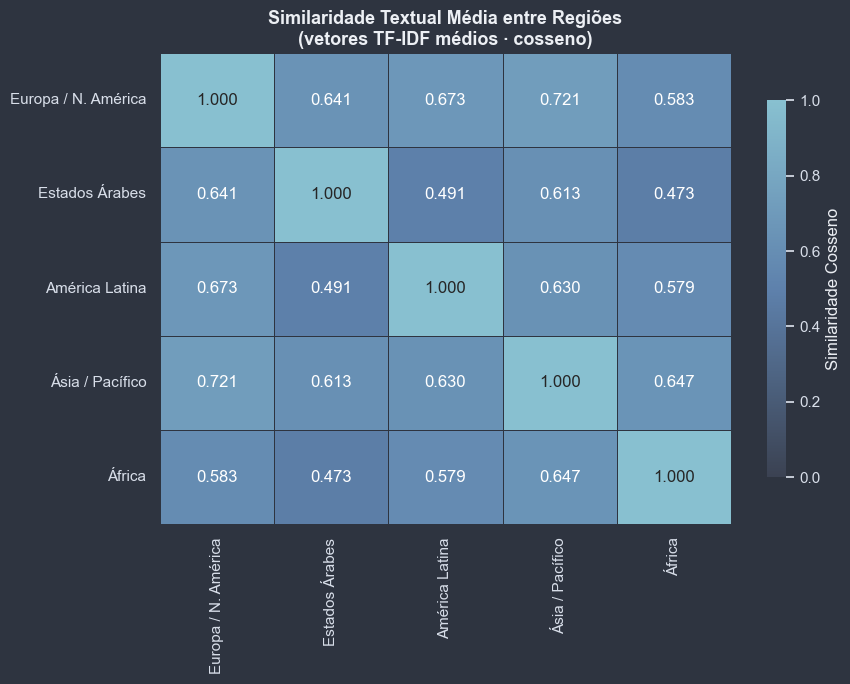

Top 3 pares de regiões mais similares:
           região_1        região_2  similarity
Europa / N. América Ásia / Pacífico    0.721083
Europa / N. América  América Latina    0.672719
    Ásia / Pacífico          África    0.646744


In [21]:
from sklearn.metrics.pairwise import cosine_similarity

region_vecs: dict[str, np.ndarray] = {
    region: np.asarray(
        tfidf_matrix[(nlp_df["region"] == region).to_numpy()].mean(axis=0)
    ).flatten()
    for region in nlp_df["region"].dropna().unique()
}

region_names = list(region_vecs.keys())
region_matrix = np.vstack([region_vecs[r] for r in region_names])
region_sim = cosine_similarity(region_matrix)

region_sim_df = pd.DataFrame(region_sim, index=region_names, columns=region_names)
region_sim_df.index = region_sim_df.index.map(lambda r: REGION_SHORT.get(r, r))
region_sim_df.columns = region_sim_df.columns.map(lambda r: REGION_SHORT.get(r, r))

nord_seq = LinearSegmentedColormap.from_list("nord_seq", ["#3B4252", "#5E81AC", "#88C0D0"])

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    region_sim_df,
    annot=True,
    fmt=".3f",
    cmap=nord_seq,
    vmin=0.0,
    vmax=1.0,
    linewidths=0.5,
    linecolor="#2E3440",
    ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Similaridade Cosseno"},
)
ax.set_title(
    "Similaridade Textual Média entre Regiões\n(vetores TF-IDF médios · cosseno)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

upper_tri = np.triu(np.ones(region_sim_df.shape, dtype=bool), k=1)
top_pairs = (
    region_sim_df.where(upper_tri)
    .stack()
    .sort_values(ascending=False)
    .head(3)
    .rename("similarity")
    .reset_index()
    .rename(columns={"level_0": "região_1", "level_1": "região_2"})
)
print("Top 3 pares de regiões mais similares:")
print(top_pairs.to_string(index=False))